In [10]:
# 统一论文图的风格和尺寸, 方便后续拼接
import os
os.environ.setdefault("MPLCONFIGDIR", "/tmp/en_modeltest_mpl")
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm


# =========================
# 只需要改这里
# =========================
ARIAL_TTF_PATH = "/data/jychen/package/Arial/arial.ttf"
USE_ARIAL_TTF = True


_PUB_FONT_NAME = None


def load_pub_font():
    """
    手动加载 Arial.ttf，并返回字体在 matplotlib 中识别到的真实名称。
    这样可以避免系统装了 Arial 但 matplotlib 仍然找不到的问题。
    """
    global _PUB_FONT_NAME

    if _PUB_FONT_NAME is not None:
        return _PUB_FONT_NAME

    if USE_ARIAL_TTF:
        if not os.path.exists(ARIAL_TTF_PATH):
            raise FileNotFoundError(f"找不到 Arial 字体文件: {ARIAL_TTF_PATH}")

        fm.fontManager.addfont(ARIAL_TTF_PATH)
        _PUB_FONT_NAME = fm.FontProperties(fname=ARIAL_TTF_PATH).get_name()
    else:
        _PUB_FONT_NAME = "Arial"

    print(f"Using font: {_PUB_FONT_NAME}")
    return _PUB_FONT_NAME


def mm_to_inch(mm):
    return mm / 25.4


FIG_SIZE = {
    "single": 90,
    "double": 180,
}


FIG_PRESETS = {
    "single_small":  ("single", 60),
    "single_short":  ("single", 75),
    "single_medium": ("single", 75),
    "double_short":  ("double", 70),
    "double_medium": ("double", 100),
    "double_large":  ("double", 140),
}


_SHARED_FONT_SIZES = {
    "font.size": 9,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 10,
}


def set_pub_style():
    pub_font = load_pub_font()

    base = {
        "font.family": pub_font,
        "font.sans-serif": [pub_font, "Arial", "Helvetica", "Liberation Sans", "DejaVu Sans"],

        "font.weight": "normal",
        "axes.labelweight": "normal",
        "axes.titleweight": "normal",

        "pdf.fonttype": 42,
        "ps.fonttype": 42,
        "svg.fonttype": "none",

        # 让 $...$ 数学文本也尽量使用同一套 Arial 字体。
        "mathtext.fontset": "custom",
        "mathtext.rm": pub_font,
        "mathtext.it": pub_font,
        "mathtext.bf": pub_font,
        "mathtext.default": "regular",

        "axes.linewidth": 1.5,
        "xtick.major.width": 1.4,
        "ytick.major.width": 1.4,
        "xtick.minor.width": 1.1,
        "ytick.minor.width": 1.1,
        "xtick.major.size": 4.5,
        "ytick.major.size": 4.5,
        "xtick.minor.size": 2.8,
        "ytick.minor.size": 2.8,
        "xtick.direction": "in",
        "ytick.direction": "in",

        "lines.linewidth": 1.7,
        "patch.linewidth": 1.3,

        "legend.frameon": False,
        "legend.handlelength": 1.5,
        "legend.handletextpad": 0.4,

        "axes.unicode_minus": False,
        "axes.spines.top": True,
        "axes.spines.right": True,

        "savefig.dpi": 600,
        "figure.dpi": 120,
    }

    base.update(_SHARED_FONT_SIZES)
    mpl.rcParams.update(base)


def new_figure(mode="single", height_mm=65):
    set_pub_style()
    width_mm = FIG_SIZE[mode]
    fig, ax = plt.subplots(
        figsize=(mm_to_inch(width_mm), mm_to_inch(height_mm))
    )
    return fig, ax


def new_subplots(nrows, ncols, preset="double_medium", **kwargs):
    set_pub_style()
    mode, height_mm = FIG_PRESETS[preset]
    width_mm = FIG_SIZE[mode]

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(mm_to_inch(width_mm), mm_to_inch(height_mm)),
        **kwargs
    )
    return fig, axes


def savefig_pub(fig, filename, dpi=600, tight=False):
    if tight:
        fig.savefig(filename, dpi=dpi, bbox_inches="tight", pad_inches=0.06)
    else:
        fig.savefig(filename, dpi=dpi)


# 应用统一风格模板
set_pub_style()




Using font: Arial


# 1XQ8 Martini3IDP：弹性网络汇总分析

固定 `-ef 700 -el 0 -eunit 1:95 -idr-tune`，比较 upper cutoff **0.80、0.85、0.90 nm**。
从原始 CG PDB / ITP 重建并验证 EN，再直接在本 notebook 中统计 residue sequence separation：
`s = |i−j|`，`P(s) = N(s)/N_total`，`T(s) = P(|i−j| ≥ s)`。

只输出一张汇总图：**A** 三个 cutoff 的 EN contact maps；**B** 归一化 sequence-separation 分布；**C** 尾比例。
所有分析数据集中于 `data/`，不依赖旧 CSV 或独立分析脚本。


In [11]:
from pathlib import Path
import os, sys, json, hashlib, importlib.util
os.environ.setdefault("MPLCONFIGDIR", "/tmp/en_modeltest_mpl")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import networkx as nx

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents]
            if (p / "Monomer/alhx_700/1xq8_cg.pdb").exists())
OUT = ROOT / "Analysis/EN_modeltest/EN_network"
OUT.mkdir(parents=True, exist_ok=True)
DATA = OUT / "data"
DATA.mkdir(exist_ok=True)
PDB = ROOT / "Monomer/alhx_700/1xq8_cg.pdb"
ITP = ROOT / "Monomer/alhx_700/toppar/1xq8_cg.itp"
VERMOUTH = Path("/home/jychen/anaconda3/lib/python3.9/site-packages/vermouth")
# Load numeric libraries from the active environment before resolving local pure-Python dependencies.
import scipy.spatial
sys.path.append(str(VERMOUTH.parent))
# Select the exact installed vermouth source used by martinize2.
spec = importlib.util.spec_from_file_location("vermouth", VERMOUTH / "__init__.py",
                                            submodule_search_locations=[str(VERMOUTH)])
vermouth = importlib.util.module_from_spec(spec)
sys.modules["vermouth"] = vermouth
spec.loader.exec_module(vermouth)
from vermouth.processors.apply_rubber_band import ApplyRubberBand, make_same_region_criterion
from vermouth.molecule import Molecule
from vermouth.graph_utils import make_residue_graph
from vermouth.forcefield import ForceField
FF_DIR = VERMOUTH / "data/force_fields/martini3IDP"
ff = ForceField(directory=str(FF_DIR))
CUTOFFS = np.array([0.80, 0.85, 0.90])
REFERENCE = 0.85
REGION = (1, 95)
FC = 700.0
RMD = ff.variables.get("elastic_network_res_min_dist", 2)
BOND_TYPE = ff.variables.get("elastic_network_bond_type", 6)
print("vermouth:", vermouth.__version__, "bond type:", BOND_TYPE, "residue graph exclusion:", RMD)




vermouth: 0.12.0 bond type: 1 residue graph exclusion: 2


## 构建规则与精度

- 默认选择 `atomname == BB`；`1:95` 两端包含，两个残基都必须在此区间。
- 排除残基共价图最短路径长度 ≤2 的配对；对这条连续线性链等价于排除 |i−j|≤2，但计算直接使用图。
- 本地力场写有 `res_min_dist 3`，处理器读取的键却是 `elastic_network_res_min_dist`，所以实际回退值为 **2**。不能把前者当成生效参数。
- `-ea 0 -ep 1 -em 0` 为 CLI 默认值；所有保留的键力常数为 700 kJ mol⁻¹ nm⁻²。距离 ≤`eu` 保留，先筛选再将平衡长度四舍五入到 5 位。`el` 是衰减平移参数，在本组零衰减参数下不是硬下限。
- PDB Å 转 nm；不使用周期性边界，符合处理器实现。只计 i<j。
- 本模型 EN 为 **bond type 1**，按 `; Rubber band` 段提取，不按 type 筛选。
- PDB 坐标保留 0.001 Å，重读坐标与 martinize2 内部未舍入坐标可能略有不同。距离误差保守上界为 √3×0.0001 nm；每个 cutoff 同时给出此误差带内可能变动的配对数与数量上下界。这不是构象统计误差。

ITP 头部另外记录 `-id-regions 96:140 -dssp ... -maxwarn 1`，比题述命令更完整。以现有 CG/ITP 为分析对象，不推断省略参数后的重新映射结果。

In [12]:
atoms, entries = {}, []
section = group = ""
for line in ITP.read_text().splitlines():
    s = line.strip()
    if s.startswith("["):
        section = s.strip("[] "); group = ""; continue
    if s.startswith(";"):
        group = s[1:].strip(); continue
    if not s or s.startswith("#"): continue
    t = s.split(";")[0].split()
    if section == "atoms":
        atoms[int(t[0])] = dict(resid=int(t[2]), resname=t[3], atomname=t[4])
    elif section in ("bonds", "constraints"):
        entries.append((section, group, t))
records = []
for line in PDB.read_text().splitlines():
    if line.startswith(("ATOM  ", "HETATM")):
        records.append(dict(serial=int(line[6:11]), atomname=line[12:16].strip(),
                            resname=line[17:20].strip(), chain=line[21].strip(),
                            resid=int(line[22:26]), insertion_code=line[26].strip(),
                            position=np.array([float(line[a:b]) for a,b in [(30,38),(38,46),(46,54)]])/10))
assert len(records) == len(atoms)
mol = Molecule(force_field=ff)
for idx, rec in enumerate(records, 1):
    assert idx == rec['serial'] and all(rec[k] == atoms[idx][k] for k in atoms[idx])
    mol.add_node(idx, **rec, _old_resid=rec['resid'])
reference = {}
for sec, grp, t in entries:
    i,j = int(t[0]), int(t[1])
    if sec == "bonds" and grp == "Rubber band":
        key = tuple(sorted((i,j)))
        assert key not in reference
        reference[key] = (int(t[2]), float(t[3]), float(t[4]))
    else:
        mol.add_edge(i,j)
# This topology contains only adjacent inter-residue covalent bonds/constraints.
# Abort rather than silently treating any nonlocal structural bond as a covalent edge.
resgraph = make_residue_graph(mol)
assert nx.is_connected(resgraph)
assert len(resgraph) == 140 and len(resgraph.edges) == 139
assert all(abs(resgraph.nodes[i]['resid'] - resgraph.nodes[j]['resid']) == 1 for i,j in resgraph.edges)
assert len({r['chain'] for r in records}) == 1
bb = [i for i in mol if mol.nodes[i]['atomname'] == 'BB']
assert len(bb) == 140
print(f"Matched {len(atoms)} beads, {len(bb)} BB residues; ITP Rubber band: {len(reference)} bonds")



Matched 295 beads, 140 BB residues; ITP Rubber band: 227 bonds


In [13]:
res_to_node = {d['resid']: node for node,d in resgraph.nodes(data=True)}
paths = dict(nx.all_pairs_shortest_path_length(resgraph))
rows = []
for a,i in enumerate(bb):
    for j in bb[a+1:]:
        ri,rj = mol.nodes[i]['resid'], mol.nodes[j]['resid']
        gd = paths[res_to_node[ri]][res_to_node[rj]]
        rows.append(dict(atom_i=i,atom_j=j,resid_i=ri,resid_j=rj,
                         distance_nm=float(np.linalg.norm(mol.nodes[i]['position']-mol.nodes[j]['position'])),
                         graph_distance=gd, in_unit=REGION[0]<=ri<=REGION[1] and REGION[0]<=rj<=REGION[1],
                         eligible=gd>RMD and REGION[0]<=ri<=REGION[1] and REGION[0]<=rj<=REGION[1]))
pairs = pd.DataFrame(rows)
def generate_en(cutoff):
    m = mol.copy()
    ApplyRubberBand(lower_bound=0, upper_bound=float(cutoff), decay_factor=0,
                    decay_power=1, base_constant=FC, minimum_force=0,
                    domain_criterion=make_same_region_criterion([REGION])).run_molecule(m)
    return {tuple(sorted(b.atoms)): tuple(b.parameters) for b in m.interactions.get('bonds', [])
            if b.meta.get('group') == 'Rubber band'}
actual = generate_en(REFERENCE)
missing = sorted(reference.keys() - actual.keys())
extra = sorted(actual.keys() - reference.keys())
assert not missing and not extra, (missing,extra)
assert all(v[0] == BOND_TYPE and v[2] == FC for v in reference.values())
assert all(v[0] == BOND_TYPE and v[2] == FC for v in actual.values())
length_errors = [abs(actual[k][1]-reference[k][1]) for k in reference]
EPS = np.sqrt(3)*0.0001
assert max(length_errors) <= EPS + 1e-5
validation = dict(reference_cutoff_nm=REFERENCE, itp_count=len(reference), rebuilt_count=len(actual),
                  missing_pairs=missing, extra_pairs=extra,
                  max_equilibrium_length_error_nm=float(max(length_errors)),
                  pair_identity_passed=True)
print(json.dumps(validation, indent=2))


{
  "reference_cutoff_nm": 0.85,
  "itp_count": 227,
  "rebuilt_count": 227,
  "missing_pairs": [],
  "extra_pairs": [],
  "max_equilibrium_length_error_nm": 9.999999999998899e-05,
  "pair_identity_passed": true
}


## 三个 cutoff 的 EN 配对与 sequence-separation 统计

每个 cutoff 均与实际 `ApplyRubberBand` 处理器核对配对集合。0.85 nm 还需与原始 ITP 的 227 条键逐对一致。
每条无向键仅计一次；contact map 对称显示不增加计数。各分布以各自键总数归一化。
分位数采用 NumPy 默认线性插值；分箱仅用于描述，不作为 “long-range” 的唯一物理定义。


In [14]:
EXPECTED = {0.80: 179, 0.85: 227, 0.90: 255}
networks, summary_rows, pair_tables, top_tables = {}, [], [], []
support = np.arange(REGION[1] - REGION[0] + 1)  # 0–94, including all zero tails
distribution = pd.DataFrame({"sequence_separation": support})

for cutoff in CUTOFFS:
    generated = generate_en(cutoff)
    selected = pairs.loc[pairs.eligible & (pairs.distance_nm <= cutoff),
                         ['atom_i','atom_j','resid_i','resid_j','distance_nm','graph_distance']].copy()
    assert set(generated) == set(zip(selected.atom_i, selected.atom_j))
    assert len(selected) == EXPECTED[float(cutoff)]
    selected = selected.rename(columns={'resid_i':'residue_i','resid_j':'residue_j'})
    selected.insert(0, 'cutoff_nm', cutoff)
    selected['sequence_separation'] = abs(selected.residue_i-selected.residue_j)
    selected['bond_type'] = BOND_TYPE
    selected['force_constant'] = FC
    selected['equilibrium_length_nm'] = [generated[(i,j)][1] for i,j in zip(selected.atom_i,selected.atom_j)]
    networks[float(cutoff)] = selected
    pair_tables.append(selected)
    top_tables.append(selected.sort_values(['sequence_separation','residue_i','residue_j'],
                       ascending=[False,True,True]).head(20))
    s = selected.sequence_separation.to_numpy()
    total = len(s)
    row = dict(cutoff_nm=cutoff, total_bonds=total, min=int(s.min()), max=int(s.max()),
               mean=float(s.mean()), median=float(np.median(s)))
    for q in (25,75,90,95): row[f'percentile_{q}'] = float(np.percentile(s,q))
    masks = {'le5':s<=5, '6to10':(s>=6)&(s<=10), '11to20':(s>=11)&(s<=20),
             '21to30':(s>=21)&(s<=30), 'gt30':s>30}
    for label,mask in masks.items():
        row[f'count_{label}'] = int(mask.sum())
        row[f'percent_{label}'] = float(100*mask.mean())
    for threshold in (10,20,30,40): row[f'fraction_ge{threshold}'] = float((s>=threshold).mean())
    distances = pairs.loc[pairs.eligible,'distance_nm']
    row['en_count_lower'] = int((distances <= cutoff-EPS).sum())
    row['en_count_upper'] = int((distances <= cutoff+EPS).sum())
    row['boundary_sensitive_pairs'] = int((abs(distances-cutoff)<=EPS).sum())
    summary_rows.append(row)
    tag = f'{cutoff:.2f}'.replace('.','p')
    counts = np.bincount(s,minlength=len(support))
    probability = counts/total
    tail = np.cumsum(counts[::-1])[::-1]/total
    assert counts.sum()==total and np.isclose(probability.sum(),1)
    assert tail[0]==1 and (np.diff(tail)<=0).all()
    distribution[f'count_{tag}'] = counts
    distribution[f'probability_{tag}'] = probability
    distribution[f'tail_fraction_{tag}'] = tail
summary = pd.DataFrame(summary_rows)
all_bonds = pd.concat(pair_tables,ignore_index=True)
top20 = pd.concat(top_tables,ignore_index=True)
all_bonds.to_csv(DATA/'elastic_bond_pairs.csv',index=False)
distribution.to_csv(DATA/'sequence_separation_distribution.csv',index=False)
summary.to_csv(DATA/'sequence_separation_summary.csv',index=False)
top20.to_csv(DATA/'sequence_separation_top20.csv',index=False)
print(summary[['cutoff_nm','total_bonds','min','max','mean','median','percent_le5','fraction_ge10']].to_string(index=False))
print('Full percentiles, bins, tail thresholds and top-20 pairs are saved in data/.')


 cutoff_nm  total_bonds  min  max     mean  median  percent_le5  fraction_ge10
      0.80          179    3    5 3.558659     4.0   100.000000            0.0
      0.85          227    3    5 3.841410     4.0   100.000000            0.0
      0.90          255    3    6 3.956863     4.0    99.607843            0.0
Full percentiles, bins, tail thresholds and top-20 pairs are saved in data/.


## 整合汇总图

A 保持为一个整体 panel，内部显示三个 EN contact maps。B/C 为原 sequence-separation 分布与尾比例；D/E 分别加入最后 1.5 us 的 total protein density 与 neighbor-number distribution，并用黑色虚线显示 IDP50 基准。panel 字母 A-E 使用 26 号。


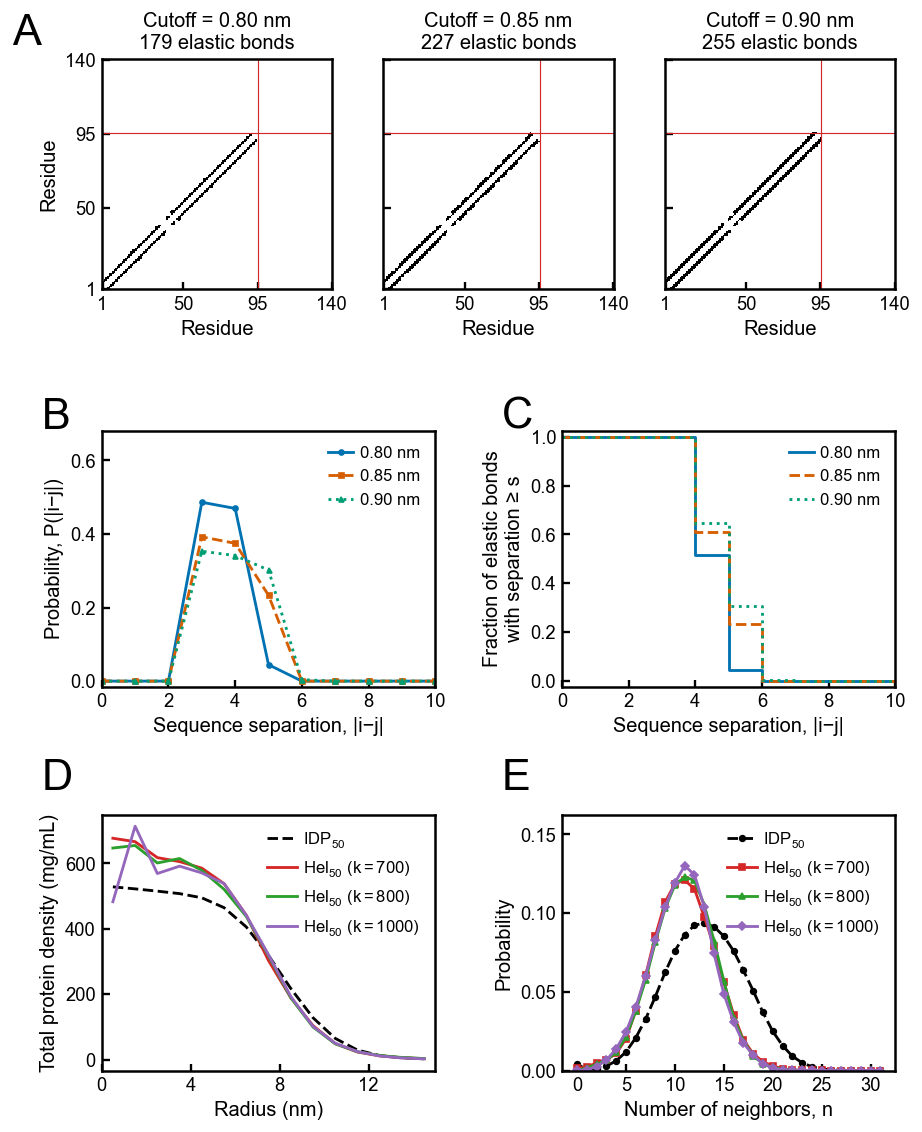

In [15]:
from matplotlib.ticker import MaxNLocator
set_pub_style()
PANEL_FS = 26

DENSITY_DIR = ROOT / 'Analysis/EN_modeltest/diff_k_density'
NEIGHBOR_DIR = ROOT / 'Analysis/EN_modeltest/diff_k_neighb'
IDP_DENSITY_FILE = ROOT / 'Analysis/rdf/segment_density_IDP_v2.txt'
IDP_NEIGHBOR_FILE = ROOT / 'Analysis/inter-chain/combined_alhx_0.txt'

system_styles = {
    '700': {'label': r'$\mathrm{Hel}_{50}$ ($k=700$)', 'color': '#d62728', 'marker': 's'},
    '800': {'label': r'$\mathrm{Hel}_{50}$ ($k=800$)', 'color': '#2ca02c', 'marker': '^'},
    '1000': {'label': r'$\mathrm{Hel}_{50}$ ($k=1000$)', 'color': '#9467bd', 'marker': 'D'},
}

# ---------- load density profiles ----------
density_profiles = pd.read_csv(
    DENSITY_DIR / 'segment_density_profiles_alhx_700_800_1000_last_1.5us.csv'
)
idp_density = np.atleast_2d(np.loadtxt(IDP_DENSITY_FILE))
idp_density_radius = idp_density[:, 0]
idp_total_density = idp_density[:, 1:].sum(axis=1)

# ---------- load neighbor-number distributions ----------
neigh_data = {
    'IDP50': np.atleast_1d(np.loadtxt(IDP_NEIGHBOR_FILE, dtype=int)),
}
for sid in system_styles:
    neigh_data[sid] = np.atleast_1d(
        np.loadtxt(NEIGHBOR_DIR / f'combined_alhx_{sid}_last_1.5us.txt', dtype=int)
    )
neigh_x_min = int(min(vals.min() for vals in neigh_data.values()))
neigh_x_max = int(max(vals.max() for vals in neigh_data.values()))
neigh_x = np.arange(neigh_x_min, neigh_x_max + 1)
neigh_prob = {}
for key, vals in neigh_data.items():
    counts = np.bincount(vals - neigh_x_min, minlength=len(neigh_x)).astype(float)
    neigh_prob[key] = counts / counts.sum()

# ---------- combined figure ----------
fig = plt.figure(figsize=(mm_to_inch(200), mm_to_inch(250)))
grid = fig.add_gridspec(
    3, 1,
    height_ratios=[1.0, 0.92, 0.92],
    left=0.14, right=0.98, bottom=0.075, top=0.955,
    hspace=0.42,
)

# A: contact maps as one grouped panel.
topgrid = grid[0].subgridspec(1, 3, wspace=0.22)
map_axes = []
for k, cutoff in enumerate(CUTOFFS):
    ax = fig.add_subplot(topgrid[0, k])
    map_axes.append(ax)
    selected = networks[float(cutoff)]
    matrix = np.zeros((140, 140), dtype=int)
    for row in selected.itertuples():
        matrix[row.residue_i - 1, row.residue_j - 1] = 1
        matrix[row.residue_j - 1, row.residue_i - 1] = 1
    assert matrix.sum() == 2 * len(selected)
    ax.imshow(
        matrix, origin='lower', extent=(0.5, 140.5, 0.5, 140.5), cmap='Greys',
        vmin=0, vmax=1, interpolation='nearest'
    )
    ax.axvline(95.5, color='tab:red', lw=0.7)
    ax.axhline(95.5, color='tab:red', lw=0.7)
    ax.set(
        title=f'Cutoff = {cutoff:.2f} nm\n{len(selected)} elastic bonds',
        xlabel='Residue', xticks=[1, 50, 95, 140], yticks=[1, 50, 95, 140]
    )
    if k == 0:
        ax.set_ylabel('Residue')
    else:
        ax.tick_params(labelleft=False)
fig.text(0.045, 0.970, 'A', fontsize=PANEL_FS, va='top')

# B-E: original sequence-separation plots plus density and neighbor-number distribution.
bottomgrid = grid[1:].subgridspec(2, 2, wspace=0.38, hspace=0.50)
ax_b = fig.add_subplot(bottomgrid[0, 0])
ax_c = fig.add_subplot(bottomgrid[0, 1])
ax_d = fig.add_subplot(bottomgrid[1, 0])
ax_e = fig.add_subplot(bottomgrid[1, 1])

styles = [('#0072B2', '-', 'o'), ('#D55E00', '--', 's'), ('#009E73', ':', '^')]
for cutoff, (color, ls, marker) in zip(CUTOFFS, styles):
    tag = f'{cutoff:.2f}'.replace('.', 'p')
    ax_b.plot(
        support, distribution[f'probability_{tag}'], label=f'{cutoff:.2f} nm',
        color=color, ls=ls, marker=marker, markersize=3
    )
    ax_c.step(
        support, distribution[f'tail_fraction_{tag}'], where='post', label=f'{cutoff:.2f} nm',
        color=color, ls=ls
    )
max_separation = int(all_bonds.sequence_separation.max())
plot_max = min(int(support.max()), max(10, max_separation + 4))
for ax in (ax_b, ax_c):
    ax.set_xlabel('Sequence separation, |i−j|')
    ax.set_xlim(0, plot_max)
    ax.legend(loc='upper right')
ax_b.set_ylabel('Probability, P(|i−j|)')
ax_b.set_ylim(-0.015, min(1.025, distribution.filter(like='probability_').to_numpy().max() * 1.4))
ax_c.set_ylabel('Fraction of elastic bonds\nwith separation ≥ s')
ax_c.set_ylim(-0.025, 1.025)

# D: total protein density comparison, with IDP50 baseline.
ax_d.plot(
    idp_density_radius, idp_total_density,
    color='black', lw=mpl.rcParams['lines.linewidth'], ls='--', label=r'$\mathrm{IDP}_{50}$'
)
for sid, style in system_styles.items():
    sub = density_profiles[density_profiles['system'] == f'alhx_{sid}']
    ax_d.plot(
        sub['radius_nm'], sub['Total Protein'],
        color=style['color'], lw=mpl.rcParams['lines.linewidth'], label=style['label']
    )
ax_d.set_xlabel('Radius (nm)')
ax_d.set_ylabel('Total protein density (mg/mL)')
ax_d.set_xlim(0, 15)
ax_d.xaxis.set_major_locator(MaxNLocator(nbins=4))
ax_d.yaxis.set_major_locator(MaxNLocator(nbins=4))
ax_d.legend(frameon=False, loc='upper right', handlelength=1.8)

# E: neighbor-number distribution, with IDP50 baseline.
ax_e.plot(
    neigh_x, neigh_prob['IDP50'],
    color='black', marker='o', markersize=3.4, linewidth=mpl.rcParams['lines.linewidth'],
    linestyle='--', label=r'$\mathrm{IDP}_{50}$'
)
for sid, style in system_styles.items():
    ax_e.plot(
        neigh_x, neigh_prob[sid],
        color=style['color'], marker=style['marker'], markersize=3.4,
        linewidth=mpl.rcParams['lines.linewidth'], label=style['label']
    )
ax_e.set_xlabel('Number of neighbors, n')
ax_e.set_ylabel('Probability')
ax_e.xaxis.set_major_locator(MaxNLocator(nbins=7, integer=True))
ax_e.set_ylim(0, max(prob.max() for prob in neigh_prob.values()) * 1.25)
ax_e.legend(frameon=False, loc='upper right', handlelength=1.8)

panel_label_pos = {
    'B': (-0.18, 1.13),
    'C': (-0.18, 1.13),
    'D': (-0.18, 1.22),
    'E': (-0.18, 1.22),
}
for ax, label in [(ax_b, 'B'), (ax_c, 'C'), (ax_d, 'D'), (ax_e, 'E')]:
    x_label, y_label = panel_label_pos[label]
    ax.text(x_label, y_label, label, transform=ax.transAxes, fontsize=PANEL_FS,
            va='top', ha='left')

savefig_pub(fig, OUT / 'EN_modeltest_summary_ABCDE.png', dpi=600, tight=True)
savefig_pub(fig, OUT / 'EN_modeltest_summary_ABCDE.pdf', tight=True)
plt.show()


In [16]:
def sha256(path): return hashlib.sha256(path.read_bytes()).hexdigest()
source_paths=[PDB,ITP,VERMOUTH/'processors/apply_rubber_band.py',VERMOUTH/'graph_utils.py',
              VERMOUTH/'selectors.py',Path('/home/jychen/anaconda3/bin/martinize2'),*sorted(FF_DIR.glob('*.ff'))]
provenance=dict(python=sys.version,vermouth_version=vermouth.__version__,numpy_version=np.__version__,
                forcefield='martini3IDP',region=REGION,force_constant=FC,lower_bound=0,
                decay_factor=0,decay_power=1,minimum_force=0,bond_type=BOND_TYPE,
                residue_graph_exclusion=RMD,pdb_rounding_distance_bound_nm=float(EPS),
                sources={str(p):sha256(p) for p in source_paths},validation=validation,
                cutoffs_nm=CUTOFFS.tolist(),figure_size_mm=[200,175])
(DATA/'provenance.json').write_text(json.dumps(provenance,indent=2))
print('Validation passed. One combined figure and analysis tables saved.')


Validation passed. One combined figure and analysis tables saved.


## 文件与复现

- `EN_modeltest_summary_ABCDE.png` / `EN_modeltest_summary_ABCDE.pdf`：整合后的 A-E 大图。
- `EN_summary.png` / `EN_summary.pdf`：旧版汇总图文件名不再由当前绘图 cell 更新。
- `data/elastic_bond_pairs.csv`：三个 cutoff 的唯一 EN 原子对、残基对、距离与 separation。
- `data/sequence_separation_distribution.csv`：完整的计数、归一化分布、包含等号的尾比例。
- `data/sequence_separation_summary.csv`：总数、分位数、分箱和阈值统计，以及 PDB 舍入边界检查。
- `data/provenance.json`：输入/源码哈希、参数和原 ITP 验证结果。

D/E 依赖 `Analysis/EN_modeltest/diff_k_density/` 与 `Analysis/EN_modeltest/diff_k_neighb/` 中已经生成的最后 1.5 us 分析结果。
